# Univariate Analysis

In [9]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

C:\Users\Tom\AppData\Local\Temp\ipykernel_8604\361401215.py:6: DtypeWarning: Columns (0: Assay Subcellular Fraction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')


* Filtering on Standard Type to get comparable types
* Dropping null columns

In [37]:
filtered = df[df['Standard Type'] == 'Potency']
print(filtered['Standard Units'].value_counts())
print()
print(filtered.columns[filtered.isna().all()])
filtered_2 = filtered.dropna(axis=1, how='all')
print(filtered_2.info())

Standard Units
nM    107577
Name: count, dtype: int64

Index(['Standard Relation', 'pChEMBL Value', 'Data Validity Comment', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value'], dtype='str')
<class 'pandas.DataFrame'>
Index: 107577 entries, 45 to 113187
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Molecule ChEMBL ID   107577 non-null  str    
 1   Molecule Name        640 non-null     str    
 2   Molecule Max Phase   394 non-null     float64
 3   Molecular Weight     107562 non-null  float64
 4   #RO5 Violations      107497 non-null  float64
 5   AlogP                107497 

* Analyse the distribution of Standard Value

count    107577.000000
mean      14203.889950
std        9288.042878
min           1.200000
25%        7943.300000
50%       11220.200000
75%       22387.200000
max       44668.400000
Name: Standard Value, dtype: float64
0.5513542958101159
-0.9513845685167439


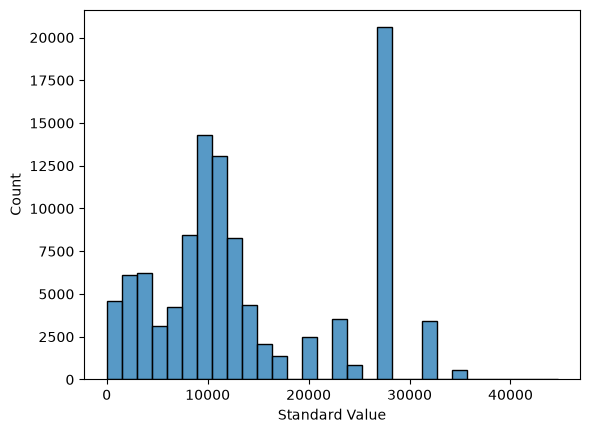

(20585, 28)
Standard Value
28183.8    20585
Name: count, dtype: int64
Molecule ChEMBL ID     20551
Molecule Name             84
Molecule Max Phase         5
Molecular Weight        8722
#RO5 Violations            4
AlogP                    754
Compound Key           20579
Smiles                 20544
Standard Type              1
Standard Value             1
Standard Units             1
Comment                    2
Uo Units                   1
Potential Duplicate        1
Assay ChEMBL ID            2
Assay Description          2
Assay Type                 1
BAO Format ID              1
BAO Label                  1
Assay Organism             1
Target ChEMBL ID           1
Target Name                1
Target Organism            1
Target Type                1
Document ChEMBL ID         1
Source ID                  1
Source Description         1
Value                      1
dtype: int64
Comment
inconclusive    17843
inactive         2742
Name: count, dtype: int64


In [ ]:
print(filtered_2['Standard Value'].describe())
print(filtered_2['Standard Value'].skew())
print(filtered_2['Standard Value'].kurt())
sns.histplot(filtered_2['Standard Value'], bins=30)


* Investigating the outlier bin in Standard Value histogram

In [64]:
mask = (filtered_2['Standard Value'] > 27000) & (filtered_2['Standard Value'] < 29000)
outliers = filtered_2[mask]
print(outliers['Standard Value'].value_counts(),'\n')
print(outliers.nunique(), '\n')
print(outliers['Comment'].value_counts())

Standard Value
28183.8    20585
Name: count, dtype: int64 

Molecule ChEMBL ID     20551
Molecule Name             84
Molecule Max Phase         5
Molecular Weight        8722
#RO5 Violations            4
AlogP                    754
Compound Key           20579
Smiles                 20544
Standard Type              1
Standard Value             1
Standard Units             1
Comment                    2
Uo Units                   1
Potential Duplicate        1
Assay ChEMBL ID            2
Assay Description          2
Assay Type                 1
BAO Format ID              1
BAO Label                  1
Assay Organism             1
Target ChEMBL ID           1
Target Name                1
Target Organism            1
Target Type                1
Document ChEMBL ID         1
Source ID                  1
Source Description         1
Value                      1
dtype: int64 

Comment
inconclusive    17843
inactive         2742
Name: count, dtype: int64


* Excluded 28183.8 nM values and re-running distribution analysis

<Axes: xlabel='Standard Value', ylabel='Count'>

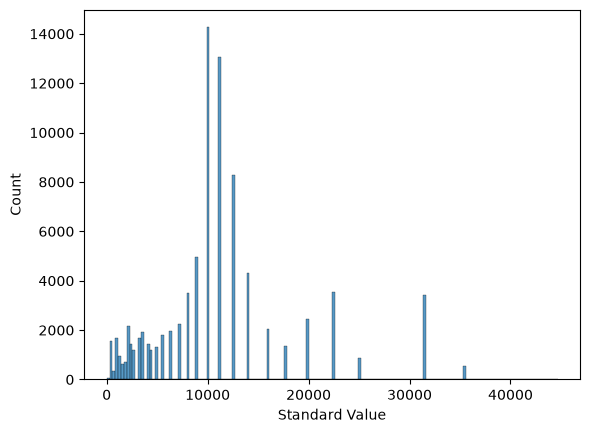

In [66]:
filtered_3 = filtered_2[filtered_2['Standard Value'] != 28183.8]
sns.histplot(filtered_3['Standard Value'])